In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from tueplots import bundles
from tabulate import tabulate
from evaluation.metrics import get_p_values_from_table_data
from evaluation.main_ihdp import get_gt_ihdp_curves, get_pred_ihdp_curves, load_data
from lifelines import KaplanMeierFitter

In [14]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
})

In [15]:
# Load the results from the stored files
save_path = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'evaluation', 'results_IHDP')
results_path = os.path.join(save_path, 'results')
plots_path = os.path.join(save_path, 'plots')

with open(os.path.join(results_path, 'results.pkl'), 'rb') as f:
    results = pickle.load(f)

settings = [key for key in results.keys()]
models = [key for key in results[settings[0]].keys()]
NUM_DATASETS = len(results[settings[0]][models[0]]['ate_error_test'])

print(f"Loaded IHDP results for {len(settings)} settings, {len(models)} models, and {NUM_DATASETS} datasets.")

Loaded IHDP results for 3 settings, 7 models, and 100 datasets.


In [16]:
# Prepare a table to show some metrics
metrics = ['ate_error_test', 'pehe_test', 'rmst_test_outcome', 'ci_td', 'ibs', 'd_calibration', 'rcll']
metric_names = ['ATE error', 'PEHE', 'RMST', 'CI', 'IBS', 'DC', 'RCLL']
higher_is_better = [False, False, False, True, False, True, True]
models_to_show = ['s-learner', 't-learner', 'tarnet', 'cfrnet', 'sa-tedvae-m0', 'sa-tedvae-m1', 'sa-tedvae-m2']

general_table = []

for setting in settings:
    table_data_mean = []
    table_data_std = []

    for model_name in models_to_show:

        tdm_mean = [setting, model_name]
        tdm_std = [setting, model_name]
        for m in metrics:
            if m in results[setting][model_name].keys():
                tdm_mean.append(f'{np.mean(results[setting][model_name][m]):.3f}')
                tdm_std.append(f'{np.std(results[setting][model_name][m]):.3f}')
            else:
                tdm_mean.append(np.nan)
                tdm_std.append(np.nan)
        table_data_mean.append(tdm_mean)
        table_data_std.append(tdm_std)

    # Add an * to the best value in each column
    for col in range(2, len(table_data_mean[0])):
        values = [float(row[col]) for row in table_data_mean]
        best_value = max(values) if higher_is_better[col - 2] else min(values)
        for irow, row in enumerate(table_data_mean):
            if float(row[col]) == best_value:
                row[col] += ' *'
            row[col] += 'pm' + str(table_data_std[irow][col])
    # Add everything to the general table
    general_table.extend(table_data_mean)

print("\nResults:")
print(tabulate(general_table, headers=['Setting', 'Model'] + [m for m in metric_names], tablefmt='latex'))


Results:
\begin{tabular}{lllllllll}
\hline
 Setting     & Model        & ATE error        & PEHE              & RMST           & CI             & IBS            & DC             & RCLL            \\
\hline
 \_survival\_a & s-learner    & 38.551pm29.034   & 62.371pm23.953    & 0.061pm0.014   & 0.615 *pm0.049 & 0.131pm0.040   & 0.991 *pm0.032 & -3.078pm0.277   \\
 \_survival\_a & t-learner    & 33.746pm23.219   & 49.819pm19.168    & 0.053pm0.011   & 0.593pm0.045   & 0.129pm0.037   & 0.980pm0.068   & -3.081pm0.277   \\
 \_survival\_a & tarnet       & 32.327pm26.388   & 34.277pm25.453    & 0.037pm0.012   & 0.602pm0.047   & 0.125pm0.035   & 0.986pm0.046   & -3.066pm0.273   \\
 \_survival\_a & cfrnet       & 33.844pm28.089   & 34.656pm27.553    & 0.037pm0.012   & 0.605pm0.052   & 0.125pm0.035   & 0.987pm0.037   & -3.064 *pm0.273 \\
 \_survival\_a & sa-tedvae-m0 & 30.247pm26.762   & 32.966pm27.635    & 0.035 *pm0.019 & 0.599pm0.043   & 0.124pm0.035   & 0.975pm0.082   & -3.064 *pm0.272 \\
 \_

In [17]:
with open(os.path.join(results_path, 'results_tmle_2.pkl'), 'rb') as f:
    results_tmle = pickle.load(f)
for setting in ['_survival_a', '_survival_b', '_survival_c']:
    pred_tmle_a = results_tmle[setting]['s-learner']['pred_tmle']
    tmle_a_list = []
    for pred_df_tmle in pred_tmle_a:

        df = pred_df_tmle.copy()
        # Keep only needed columns
        df = df[["Time", "Group", "Pt Est"]].dropna()

        # Put Group 0 and Group 1 curves side by side
        wide = (
            df
            .pivot(index="Time", columns="Group", values="Pt Est")
            .sort_index()
        )

        # Rename for clarity
        F0 = wide[0].values   # cumulative incidence for control
        F1 = wide[1].values   # cumulative incidence for treated
        time = wide.index.values

        # If Pt Est is cumulative incidence:
        # S1(t) - S0(t) = [1 - F1(t)] - [1 - F0(t)] = F0(t) - F1(t)
        survival_diff = F0 - F1

        # Area between curves, using only the available time points
        ate_tmle = np.trapezoid(survival_diff, time)
        tmle_a_list.append(ate_tmle)

    ate_real_a = [np.mean(results_tmle[setting]['s-learner']['ite_real_test'][i]) for i in range(100)]
    ate_error_a = [abs(ate_tmle_a_i - ate_real_a_i) for (ate_tmle_a_i, ate_real_a_i) in zip(tmle_a_list, ate_real_a)]

    ate_mae = np.mean(ate_error_a)
    ate_std = np.std(ate_error_a)
    print(f'{setting}: {ate_mae} +- {ate_std}')


_survival_a: 138.4788457767639 +- 11.27554795459532
_survival_b: 147.9570923603606 +- 25.527619486655006
_survival_c: 144.79771638764407 +- 14.675163194622014


In [18]:
# Statistical analysis of the results
metrics = ['ate_error_test', 'pehe_test', 'rmst_test_outcome', 'ci_td', 'ibs', 'd_calibration', 'rcll']  # Do not use CI as selection metrics
metric_names = ['ATE error', 'PEHE', 'RMST', 'CI', 'IBS', 'DC', 'RCLL']
higher_is_better = [False, False, False, True, False, True, True]
models_to_show = ['s-learner', 't-learner', 'tarnet', 'cfrnet', 'sa-tedvae-m0', 'sa-tedvae-m1', 'sa-tedvae-m2']
data = np.zeros((len(models_to_show), len(metrics), len(settings) * NUM_DATASETS))
list_of_methods = []
for j, model_name in enumerate(models_to_show):
    list_of_methods.append(model_name)
    for i, setting in enumerate(settings):
        for k, m in enumerate(metrics):
            if m in results[setting][model_name].keys():
                data[j, k, i*NUM_DATASETS:(i+1)*NUM_DATASETS] = results[setting][model_name][m]
            else:
                if higher_is_better[k]:
                    data[j, k, i*NUM_DATASETS:(i+1)*NUM_DATASETS] = -np.inf
                else:
                    data[j, k, i*NUM_DATASETS:(i+1)*NUM_DATASETS] = np.inf

get_p_values_from_table_data(data, alpha=0.05, higher_is_better=higher_is_better, output_latex=False, list_of_methods=list_of_methods, list_of_metrics=metric_names, show_data=False)


Data for metric ATE error, where higher_is_better is False:
Friedman p-value: <1e-3, Davenport p-value: <1e-3 for metric ATE error
+---------------------------------------+-------------+-------------+----------+----------+----------------+----------------+-------------------+
| Metric ATE error                      | s-learner   | t-learner   | tarnet   | cfrnet   | sa-tedvae-m0   | sa-tedvae-m1   | sa-tedvae-m2      |
+=======================================+=============+=============+==========+==========+================+================+===================+
| Average metric                        | 61.204      | 35.061      | 33.514   | 33.093   | 36.104         | 41.188         | 32.341            |
+---------------------------------------+-------------+-------------+----------+----------+----------------+----------------+-------------------+
| Paired Wilcoxon tests (uncorrected)   | <1e-3       | 0.003       | 0.014    | 0.043    | 0.082*         | <1e-3          | 1.000* (base

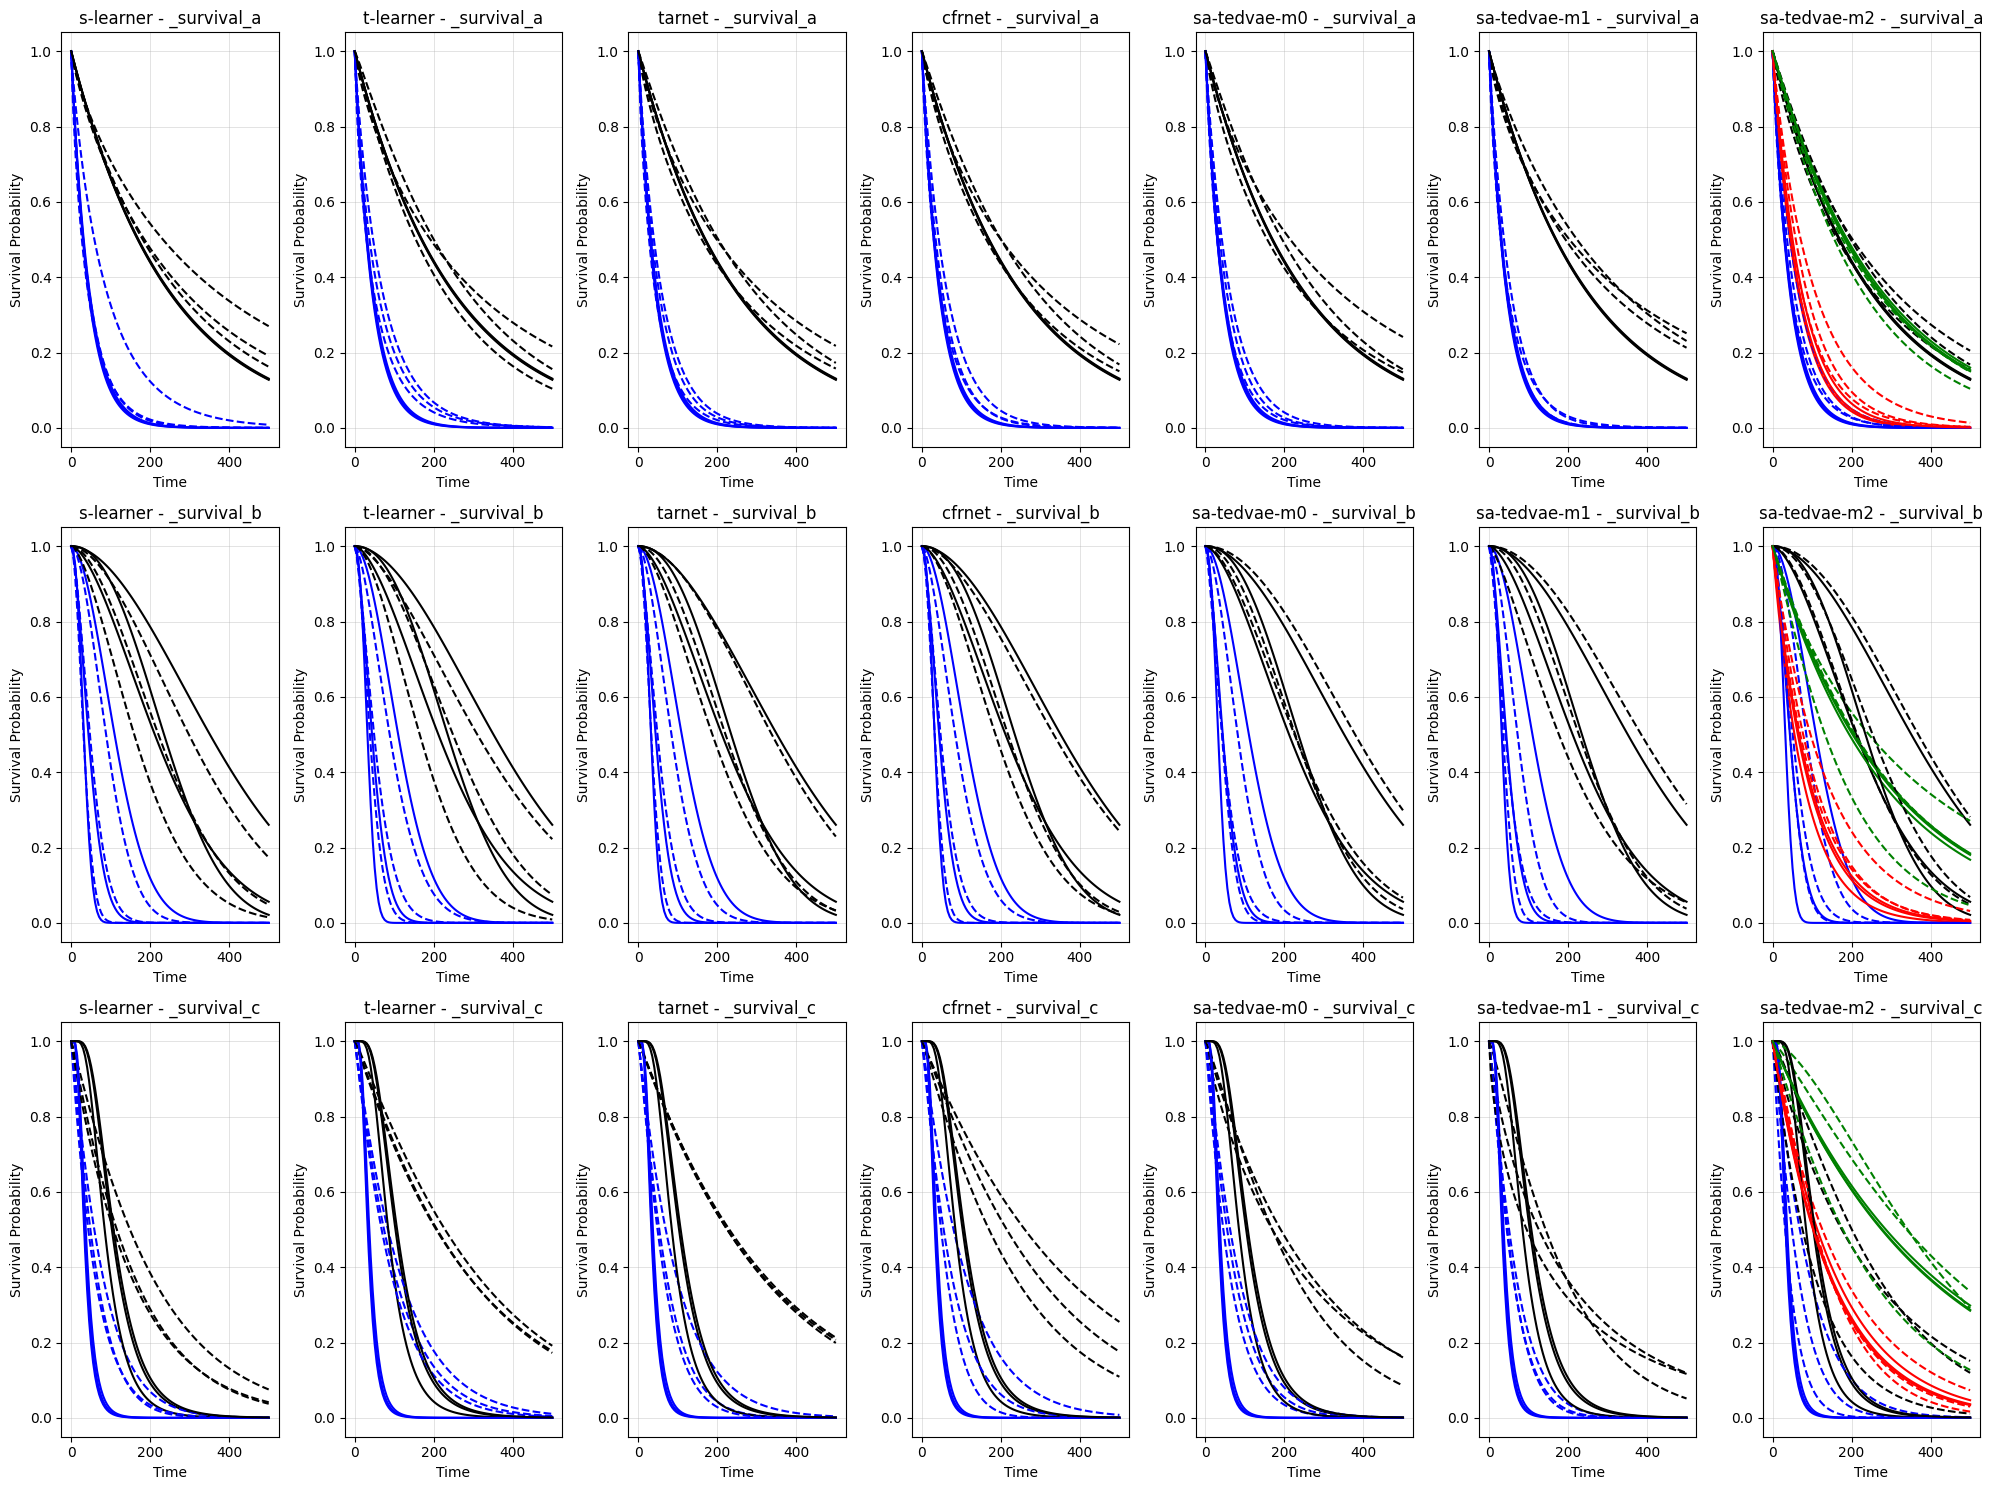

In [19]:
# Plot some curves for each setting...
n_datasets_to_plot = 3
patient_index = 0  # Change this to plot different patients
models_to_show = ['s-learner', 't-learner', 'tarnet', 'cfrnet', 'sa-tedvae-m0', 'sa-tedvae-m1', 'sa-tedvae-m2']
name_map = {'s-learner': 'S-Learner',
            't-learner': 'T-Learner',
            'tarnet': 'TARNet',
            'cfrnet': 'CFRNet',
            'sa-tedvae-m0': 'SA-TEDVAE-NIC',
            'sa-tedvae-m1': 'SA-TEDVAE-CP',
            'sa-tedvae-m2': 'SA-TEDVAE-CT',
            'tmle': 'TMLE'}
plt.subplots(len(settings), len(models_to_show), figsize=(20, 15))
model_index_plot = 1
time_vector = np.linspace(0, 500, 100)  # Vector to plot the time
for setting in settings:
    for model_name in models_to_show:

        plt.subplot(len(settings), len(models_to_show), model_index_plot)

        for i in range(n_datasets_to_plot):
            data_path = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'data', 'IHDP', 'IHDP')
            with open(f'{data_path}{setting}/ihdp_npci_params_{i + 1}.pkl', 'rb') as f:
                ground_truth_params = pickle.load(f)

            survival_train_0_censor_gt, survival_test_0_censor_gt, survival_train_1_censor_gt, survival_test_1_censor_gt, survival_train_0_outcome_gt, survival_test_0_outcome_gt, survival_train_1_outcome_gt, survival_test_1_outcome_gt = get_gt_ihdp_curves(setting, ground_truth_params, time_vector)
            data_dict = {'outcome_scale_train': [o for o in results[setting][model_name]['outcome_scale_train'][i]],
                         'outcome_scale_test': [o for o in results[setting][model_name]['outcome_scale_test'][i]],
                         'outcome_concentration_train': [o for o in results[setting][model_name]['outcome_concentration_train'][i]],
                         'outcome_concentration_test': [o for o in results[setting][model_name]['outcome_concentration_test'][i]]}
            if model_name == 'sa-tedvae-m2':
                data_dict['censor_scale_train'] = [o for o in results[setting][model_name]['censor_scale_train'][i]]
                data_dict['censor_scale_test'] = [o for o in results[setting][model_name]['censor_scale_test'][i]]
                data_dict['censor_concentration_train'] = [o for o in results[setting][model_name]['censor_concentration_train'][i]]
                data_dict['censor_concentration_test'] = [o for o in results[setting][model_name]['censor_concentration_test'][i]]
            survival_train_0_censor_pred, survival_test_0_censor_pred, survival_train_1_censor_pred, survival_test_1_censor_pred, survival_train_0_outcome_pred, survival_test_0_outcome_pred, survival_train_1_outcome_pred, survival_test_1_outcome_pred = get_pred_ihdp_curves(data_dict, time_vector)

            plt.plot(time_vector, survival_test_0_outcome_pred[:, patient_index].T, label=f"Pred 0", color='blue', linestyle='--')
            plt.plot(time_vector, survival_test_1_outcome_pred[:, patient_index].T, label=f"Pred 1", color='black', linestyle='--')
            plt.plot(time_vector, survival_test_0_outcome_gt[:, patient_index].T, label='True 0', color='blue', linestyle='-')
            plt.plot(time_vector, survival_test_1_outcome_gt[:, patient_index].T, label='True 1', color='black', linestyle='-')
            if model_name == 'sa-tedvae-m2':  # We also have the censoring in this model
                plt.plot(time_vector, survival_test_0_censor_pred[:, patient_index].T, label=f"Pred 0 c", color='red', linestyle='--')
                plt.plot(time_vector, survival_test_1_censor_pred[:, patient_index].T, label=f"Pred 1 c", color='green', linestyle='--')
                plt.plot(time_vector, survival_test_0_censor_gt[:, patient_index].T, label='True 0 c', color='red', linestyle='-')
                plt.plot(time_vector, survival_test_1_censor_gt[:, patient_index].T, label='True 1 c', color='green', linestyle='-')
        plt.title(f"{model_name} - {setting}")
        plt.xlabel("Time")
        plt.ylabel("Survival Probability")
        plt.grid(True)
        model_index_plot += 1
plt.tight_layout()
plt.show()


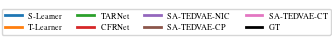

C:\Users\Alex\AppData\Local\Temp\ipykernel_27932\73651653.py:241: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


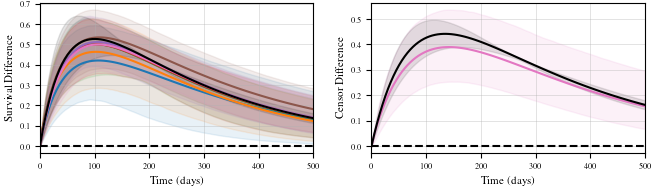

C:\Users\Alex\AppData\Local\Temp\ipykernel_27932\73651653.py:241: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


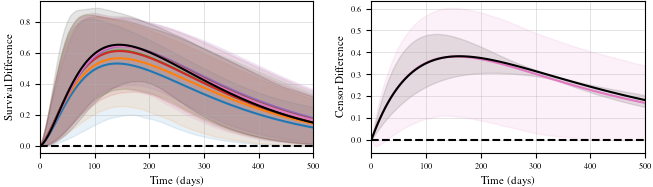

C:\Users\Alex\AppData\Local\Temp\ipykernel_27932\73651653.py:241: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


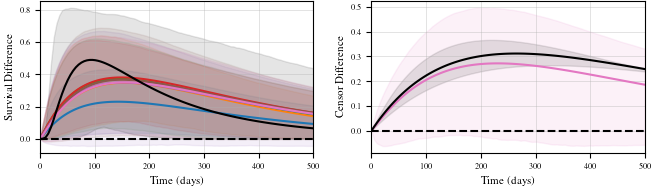

In [20]:
# Plot in detail the population estimation to compare across models
models_to_show = [
    's-learner',
    't-learner',
    'tarnet',
    'cfrnet',
    'sa-tedvae-m0',
    'sa-tedvae-m1',
    'sa-tedvae-m2'
]

max_t = 500
time_vector = np.linspace(0, max_t, 100)  # Vector to plot the time

from matplotlib.lines import Line2D

# Fixed colors shared by all plots
color_map = plt.get_cmap('tab10')

plot_colors = {
    model_name: color_map(i)
    for i, model_name in enumerate(models_to_show)
}

plot_colors["GT"] = "k"


def aux_plot(list_of_arrays, label, color, percentile=2.5):
    list_of_arrays = np.array(list_of_arrays)

    mean_val = np.mean(list_of_arrays, axis=(0, 1))
    std_val = np.std(list_of_arrays, axis=(0, 1))

    low_val = np.percentile(list_of_arrays, percentile, axis=(0, 1))
    high_val = np.percentile(list_of_arrays, 100 - percentile, axis=(0, 1))

    plt.fill_between(time_vector, low_val, high_val, color=color, alpha=0.1)
    plt.plot(time_vector, mean_val, label=label, color=color)


def plot_and_save_shared_legend(save_path):
    legend_handles = [
        Line2D(
            [0], [0],
            color=plot_colors[model_name],
            lw=2,
            label=name_map[model_name]
        )
        for model_name in models_to_show
    ]

    legend_handles.append(
        Line2D(
            [0], [0],
            color=plot_colors["GT"],
            lw=2,
            label="GT"
        )
    )

    # Same width as the main plots, but shorter height because this is only a legend
    main_width = plt.rcParams["figure.figsize"][0]
    fig_legend = plt.figure(
        figsize=(main_width/2, 0.5)
    )

    ax_legend = fig_legend.add_subplot(111)
    ax_legend.axis("off")

    ax_legend.legend(
        handles=legend_handles,
        loc="center",
        ncol=4,                 # 8 entries -> 2 rows
        mode="expand",          # occupy the full width
        frameon=True,
        bbox_to_anchor=(0, 0, 1, 1),
        borderaxespad=0,
        handlelength=2.0,
        columnspacing=1.0,
    )

    fig_legend.savefig(save_path, dpi=300, facecolor="white", bbox_inches="tight")
    plt.show()
    plt.close(fig_legend)


# Plot and save the shared legend before the first main plot
with plt.rc_context({**bundles.icml2024(column='full', nrows=1, ncols=1, usetex=True)}):
    plot_and_save_shared_legend(
        os.path.join(plots_path, 'ihdp_diff_legend.pdf')
    )


for setting in settings:
    with plt.rc_context({**bundles.icml2024(column='full', nrows=1, ncols=2, usetex=True)}):
        plt.subplots(1, 2)

        curves = {model_name: {} for model_name in models_to_show}

        for model_name in models_to_show:

            curves[model_name] = {
                'survival_test_outcome_diff': [],
                'survival_test_censor_diff': [],
                'survival_gt_outcome_diff': [],
                'survival_gt_censor_diff': []
            }

            for i in range(NUM_DATASETS):
                data_dict = {
                    'outcome_scale_train': [
                        o for o in results[setting][model_name]['outcome_scale_train'][i]
                    ],
                    'outcome_scale_test': [
                        o for o in results[setting][model_name]['outcome_scale_test'][i]
                    ],
                    'outcome_concentration_train': [
                        o for o in results[setting][model_name]['outcome_concentration_train'][i]
                    ],
                    'outcome_concentration_test': [
                        o for o in results[setting][model_name]['outcome_concentration_test'][i]
                    ]
                }

                if model_name == 'sa-tedvae-m2':
                    data_dict['censor_scale_train'] = [
                        o for o in results[setting][model_name]['censor_scale_train'][i]
                    ]
                    data_dict['censor_scale_test'] = [
                        o for o in results[setting][model_name]['censor_scale_test'][i]
                    ]
                    data_dict['censor_concentration_train'] = [
                        o for o in results[setting][model_name]['censor_concentration_train'][i]
                    ]
                    data_dict['censor_concentration_test'] = [
                        o for o in results[setting][model_name]['censor_concentration_test'][i]
                    ]

                if model_name == 'sa-tedvae-m1':
                    data_dict['survival_test_censor_prop'] = [
                        o for o in results[setting][model_name]['censor_prop_test_model'][i]
                    ]

                (
                    survival_train_0_censor_pred,
                    survival_test_0_censor_pred,
                    survival_train_1_censor_pred,
                    survival_test_1_censor_pred,
                    survival_train_0_outcome_pred,
                    survival_test_0_outcome_pred,
                    survival_train_1_outcome_pred,
                    survival_test_1_outcome_pred
                ) = get_pred_ihdp_curves(data_dict, time_vector)

                curves[model_name]['survival_test_outcome_diff'].append(
                    survival_test_1_outcome_pred.T - survival_test_0_outcome_pred.T
                )

                if model_name == 'sa-tedvae-m2':
                    curves[model_name]['survival_test_censor_diff'].append(
                        survival_test_1_censor_pred.T - survival_test_0_censor_pred.T
                    )

        # Add the ground truth
        for i in range(NUM_DATASETS):
            data_path = os.path.join(
                os.path.dirname(os.path.abspath(os.getcwd())),
                'data',
                'IHDP',
                'IHDP'
            )

            with open(f'{data_path}{setting}/ihdp_npci_params_{i + 1}.pkl', 'rb') as f:
                ground_truth_params = pickle.load(f)

            (
                survival_train_0_censor_gt,
                survival_test_0_censor_gt,
                survival_train_1_censor_gt,
                survival_test_1_censor_gt,
                survival_train_0_outcome_gt,
                survival_test_0_outcome_gt,
                survival_train_1_outcome_gt,
                survival_test_1_outcome_gt
            ) = get_gt_ihdp_curves(setting, ground_truth_params, time_vector)

            # Done like this to read the ground truth once per dataset for speed
            for model_name in models_to_show:
                curves[model_name]['survival_gt_outcome_diff'].append(
                    survival_test_1_outcome_gt.T - survival_test_0_outcome_gt.T
                )
                curves[model_name]['survival_gt_censor_diff'].append(
                    survival_test_1_censor_gt.T - survival_test_0_censor_gt.T
                )

        plt.subplot(1, 2, 1)

        for model_name in models_to_show:
            aux_plot(
                curves[model_name]['survival_test_outcome_diff'],
                label=name_map[model_name],
                color=plot_colors[model_name]
            )

        aux_plot(
            curves['sa-tedvae-m2']['survival_gt_outcome_diff'],
            label="GT",
            color=plot_colors["GT"]
        )

        plt.plot(time_vector, np.zeros_like(time_vector), color='k', linestyle='--')
        # plt.title(f"Treatment effect survival diff estimated " + setting)
        plt.xlabel("Time (days)")
        plt.ylabel("Survival Difference")
        plt.xlim([0, max_t])
        plt.grid(True)
        # plt.legend(loc='best')

        plt.subplot(1, 2, 2)

        aux_plot(
            curves['sa-tedvae-m2']['survival_test_censor_diff'],
            label=name_map['sa-tedvae-m2'],
            color=plot_colors['sa-tedvae-m2']
        )

        aux_plot(
            curves['sa-tedvae-m2']['survival_gt_censor_diff'],
            label="GT",
            color=plot_colors["GT"]
        )

        plt.plot(time_vector, np.zeros_like(time_vector), color='k', linestyle='--')
        # plt.title(f"Treatment effect survival diff estimated " + setting)
        plt.xlabel("Time (days)")
        plt.ylabel("Censor Difference")
        plt.xlim([0, max_t])
        plt.grid(True)
        # plt.legend(loc='best')

        plt.tight_layout()
        plt.rcParams.update(bundles.icml2024(usetex=False))

        plt.savefig(
            os.path.join(plots_path, f'ihdp_diff_{setting}.pdf'),
            dpi=300
        )

        plt.show()

C:\Users\Alex\AppData\Local\Temp\ipykernel_27932\1204147294.py:106: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


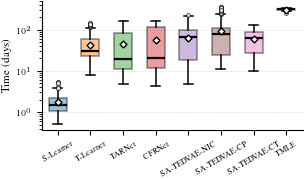

In [21]:
# Plot the training time for each model

# Load the training time data
with open(os.path.join(results_path, 'training_times.pkl'), 'rb') as f:
    training_times = pickle.load(f)

models_to_show = [
    's-learner',
    't-learner',
    'tarnet',
    'cfrnet',
    'sa-tedvae-m0',
    'sa-tedvae-m1',
    'sa-tedvae-m2'
]

tmle_times = []
for setting in settings:
    for model_name in models_to_show:
        for e in results[setting][model_name]['t_tmle']:
            if e is not None:
                tmle_times.append(e)

if len(tmle_times) > 0:
    training_times['tmle'] = tmle_times
    models_to_show.append('tmle')


with plt.rc_context({**bundles.icml2024(column='half', nrows=1, ncols=1, usetex=True)}):
    fig, ax = plt.subplots()

    data = []
    labels = []

    for model_name in models_to_show:
        values = np.asarray(training_times[model_name], dtype=float)

        # Log scale cannot display zero or negative values
        values = values[values > 0]

        data.append(values)
        labels.append(name_map.get(model_name, model_name.upper()))

    color_map = plt.get_cmap("tab10")
    colors = [
        color_map(i % 10)
        for i in range(len(models_to_show))
    ]

    box = ax.boxplot(
        data,
        patch_artist=True,
        tick_labels=labels,
        widths=0.55,
        showmeans=True,
        boxprops=dict(
            linewidth=1.1,
            color="black"
        ),
        whiskerprops=dict(
            linewidth=1.1,
            color="black"
        ),
        capprops=dict(
            linewidth=1.1,
            color="black"
        ),
        medianprops=dict(
            linewidth=1.6,
            color="black"
        ),
        meanprops=dict(
            marker="D",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=3.5
        ),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=0.6,
            markersize=2.8,
            alpha=0.7,
            linestyle="none"
        )
    )

    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)

    ax.set_ylabel("Time (days)")
    ax.set_yscale("log")

    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.grid(False, axis="x")
    ax.set_axisbelow(True)

    ax.tick_params(axis="x", rotation=30)

    # Cleaner frame
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    plt.savefig(
        os.path.join(plots_path, "ihdp_times.pdf"),
        dpi=300,
        facecolor="white",
        bbox_inches="tight"
    )

    plt.show()

C:\Users\Alex\AppData\Local\Temp\ipykernel_27932\4252092493.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


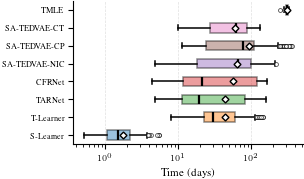

In [22]:
with plt.rc_context({**bundles.icml2024(column='half', nrows=1, ncols=1, usetex=True)}):
    fig, ax = plt.subplots()

    data = []
    labels = []

    for model_name in models_to_show:
        values = np.asarray(training_times[model_name], dtype=float)
        values = values[values > 0]

        data.append(values)
        labels.append(name_map.get(model_name, model_name.upper()))

    color_map = plt.get_cmap("tab10")
    colors = [
        color_map(i % 10)
        for i in range(len(models_to_show))
    ]

    box = ax.boxplot(
        data,
        vert=False,
        patch_artist=True,
        tick_labels=labels,
        widths=0.55,
        showmeans=True,
        boxprops=dict(linewidth=1.1, color="black"),
        whiskerprops=dict(linewidth=1.1, color="black"),
        capprops=dict(linewidth=1.1, color="black"),
        medianprops=dict(linewidth=1.6, color="black"),
        meanprops=dict(
            marker="D",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=3.5
        ),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=0.6,
            markersize=2.8,
            alpha=0.7,
            linestyle="none"
        )
    )

    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)

    ax.set_xlabel("Time (days)")
    ax.set_xscale("log")

    ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.grid(False, axis="y")
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    plt.savefig(
        os.path.join(plots_path, "ihdp_times_horizontal.pdf"),
        dpi=300,
        facecolor="white",
        bbox_inches="tight"
    )

    plt.show()

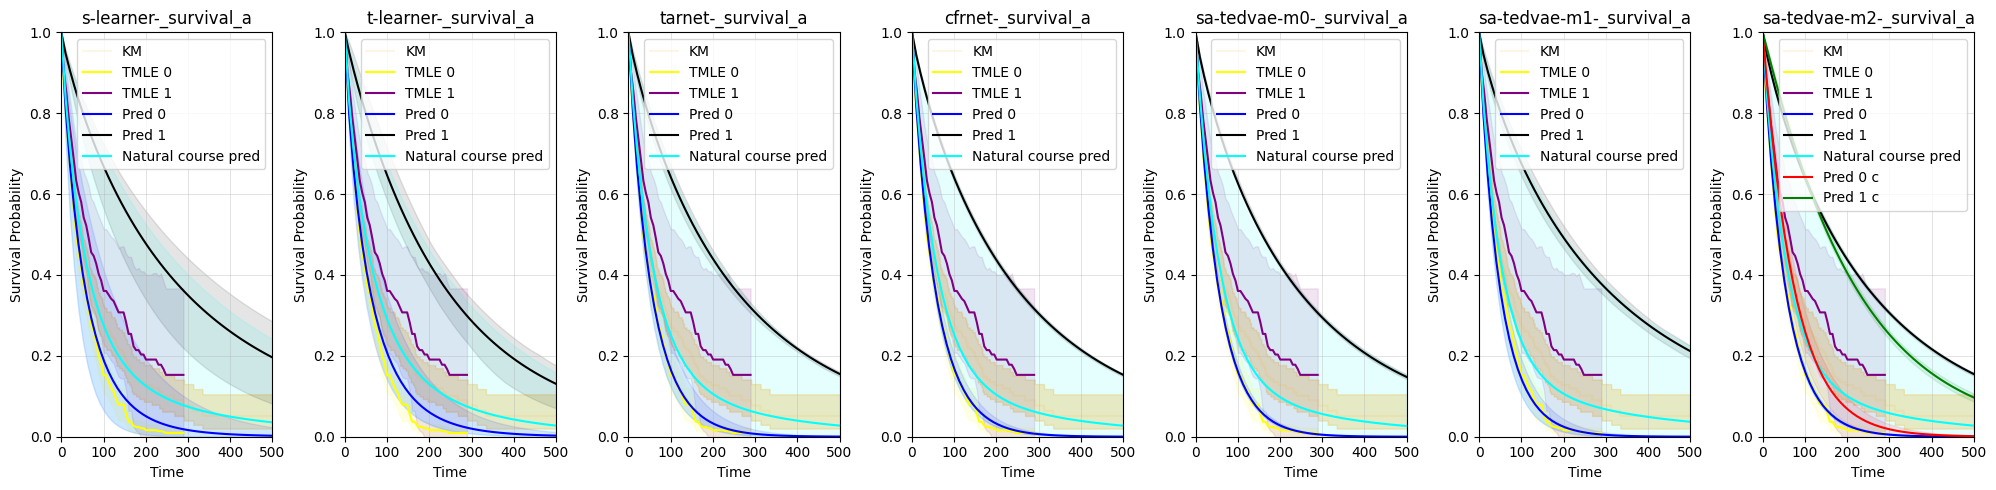

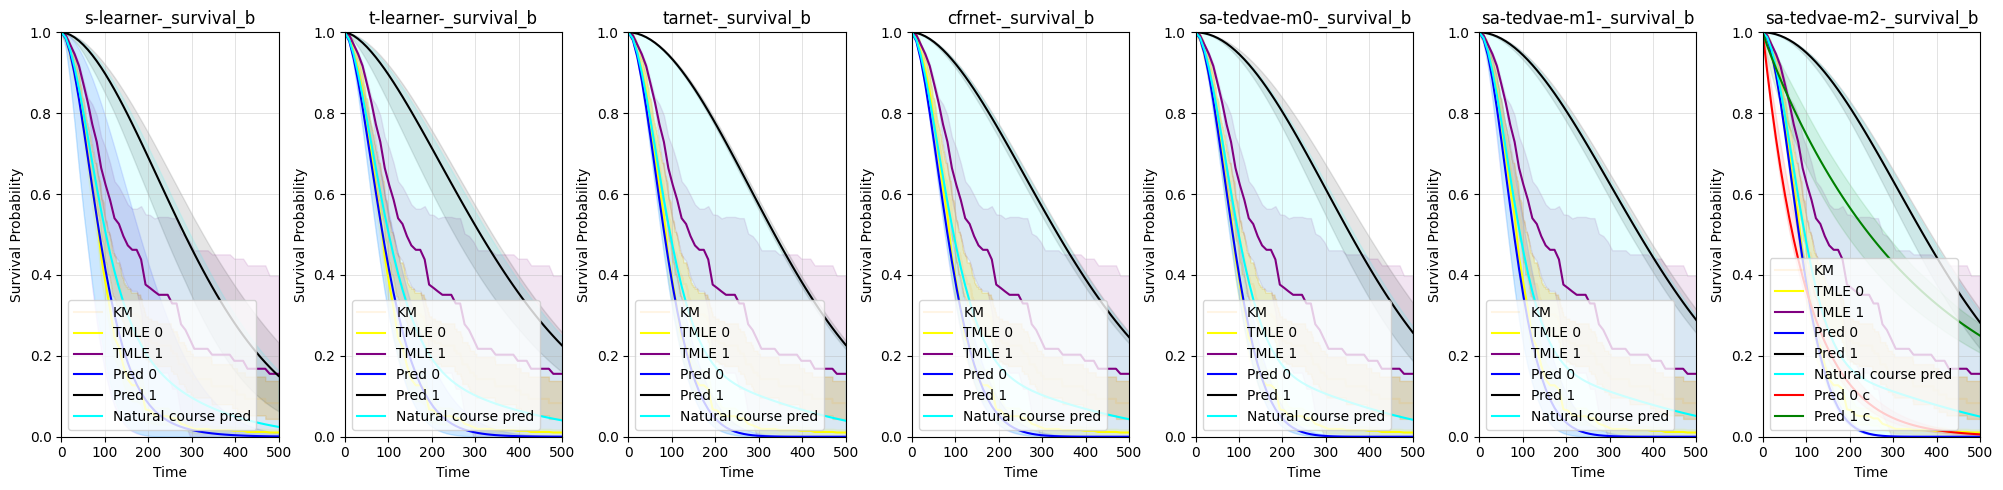

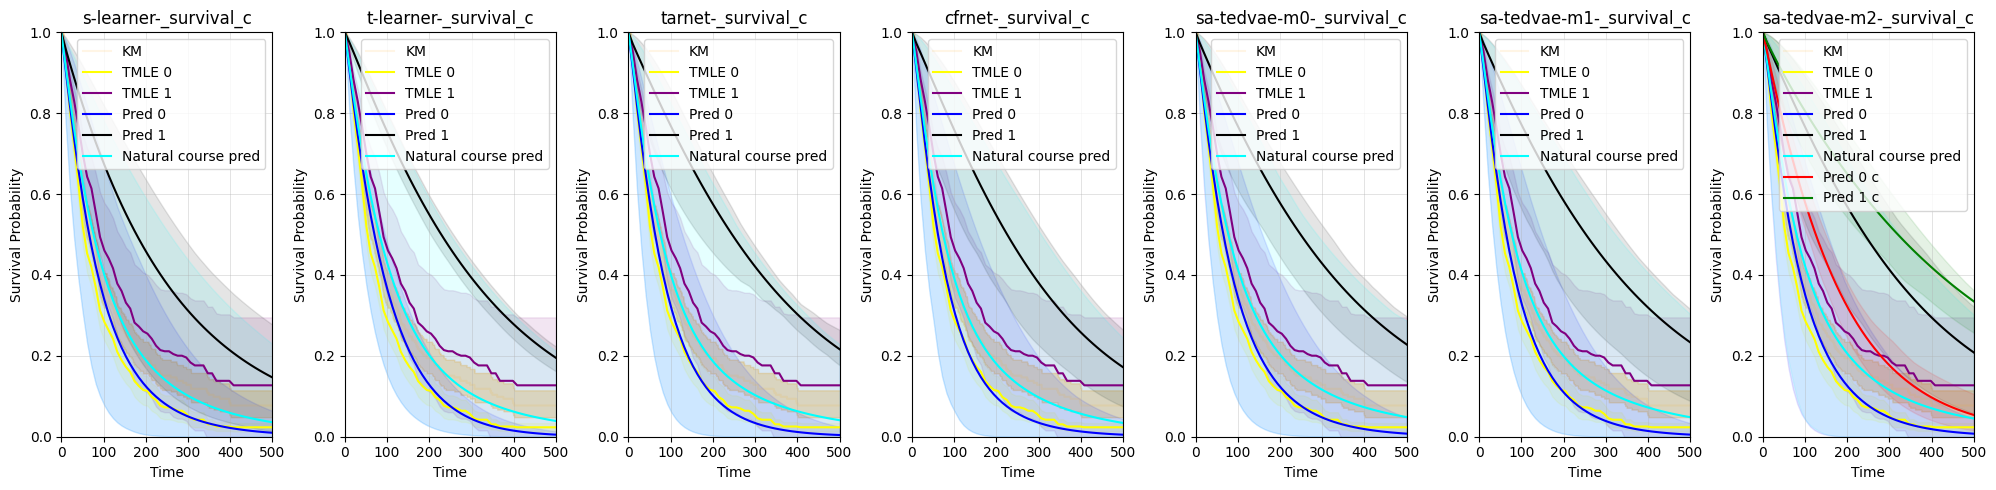

In [23]:
# Plot the aggregate predictions over all patients compared to the natural course FOR A SINGLE DATASET, WITH TMLE
max_t = 500
time_vector = np.linspace(0, max_t, 50)  # Vector to plot the time
models_to_show = ['s-learner', 't-learner', 'tarnet', 'cfrnet', 'sa-tedvae-m0', 'sa-tedvae-m1', 'sa-tedvae-m2']
i = 0  # Dataset index to plot, change this to plot different datasets

def aux_plot(arrays, label, color, percentile=2.5, additional_arrays=None, t=None):
    arrays = np.array(arrays).squeeze()
    if additional_arrays is not None:
        additional_arrays = np.array(additional_arrays).squeeze()
        new_arrays = np.zeros_like(arrays)
        for i in range(arrays.shape[0]):
            new_arrays[i, :] = additional_arrays[i, :] * t[i] + arrays[i, :] * (1 - t[i])  # Assumes additional list of arrays is t=1
        arrays = new_arrays
    mean_val, std_val = np.mean(arrays, axis=0), np.std(arrays, axis=0)
    low_val, high_val = np.percentile(arrays, percentile, axis=0), np.percentile(arrays, 100 - percentile, axis=0)
    plt.fill_between(time_vector, low_val, high_val, color=color, alpha=0.1)
    plt.plot(time_vector, mean_val, label=label, color=color)


for setting in settings:

    plt.subplots(1, len(models_to_show), figsize=(20, 5))
    model_index_plot = 1

    for model_name in models_to_show:

        plt.subplot(1, len(models_to_show), model_index_plot)

        ihdp_data = load_data(i=i + 1, setting=setting)  # Use all the data for KM
        all_y = np.concatenate([ihdp_data['y_train'], ihdp_data['y_test']])
        all_c = np.concatenate([ihdp_data['c_train'], ihdp_data['c_test']])

        kmf = KaplanMeierFitter()
        kmf.fit(all_y, event_observed=1 - all_c)
        kmf.plot_survival_function(label='KM', color='orange', alpha=0.1)

        # Add TMLE
        tmle_est = results_tmle[setting][models[0]]['pred_tmle'][i]  # Note that we store TMLE in the first model
        time0 = tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 0)]["Time"].values
        mean0 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 0)]["Pt Est"].values
        ci_lower0 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 0)]["CI_lower"].values
        ci_upper0 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 0)]["CI_upper"].values
        time1 = tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 1)]["Time"].values
        mean1 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 1)]["Pt Est"].values
        ci_lower1 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 1)]["CI_lower"].values
        ci_upper1 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 1)]["CI_upper"].values

        plt.fill_between(time0, ci_lower0, ci_upper0, alpha=0.1, color='yellow')
        plt.plot(time0, mean0, label='TMLE 0', color='yellow')
        plt.fill_between(time1, ci_lower1, ci_upper1, alpha=0.1, color='purple')
        plt.plot(time1, mean1, label='TMLE 1', color='purple')

        curves = {'survival_test_0_censor_pred': [], 'survival_test_1_censor_pred': [],
                  'survival_test_0_outcome_pred': [],
                  'survival_test_1_outcome_pred': []}

        data_dict = {'outcome_scale_train': [o for o in results[setting][model_name]['outcome_scale_train'][i]],
                     'outcome_scale_test': [o for o in results[setting][model_name]['outcome_scale_test'][i]],
                     'outcome_concentration_train': [o for o in
                                                     results[setting][model_name]['outcome_concentration_train'][i]],
                     'outcome_concentration_test': [o for o in
                                                    results[setting][model_name]['outcome_concentration_test'][i]]}
        if model_name == 'sa-tedvae-m2':
            data_dict['censor_scale_train'] = [o for o in results[setting][model_name]['censor_scale_train'][i]]
            data_dict['censor_scale_test'] = [o for o in results[setting][model_name]['censor_scale_test'][i]]
            data_dict['censor_concentration_train'] = [o for o in
                                                       results[setting][model_name]['censor_concentration_train'][i]]
            data_dict['censor_concentration_test'] = [o for o in
                                                      results[setting][model_name]['censor_concentration_test'][i]]
        survival_train_0_censor_pred, survival_test_0_censor_pred, survival_train_1_censor_pred, survival_test_1_censor_pred, survival_train_0_outcome_pred, survival_test_0_outcome_pred, survival_train_1_outcome_pred, survival_test_1_outcome_pred = get_pred_ihdp_curves(data_dict, time_vector)

        curves['survival_test_0_outcome_pred'].append(survival_test_0_outcome_pred.T)
        curves['survival_test_1_outcome_pred'].append(survival_test_1_outcome_pred.T)
        if model_name == 'sa-tedvae-m2':
            curves['survival_test_0_censor_pred'].append(survival_test_0_censor_pred.T)
            curves['survival_test_1_censor_pred'].append(survival_test_1_censor_pred.T)

        aux_plot(curves['survival_test_0_outcome_pred'], label=f"Pred 0", color='blue')
        aux_plot(curves['survival_test_1_outcome_pred'], label=f"Pred 1", color='black')
        # Add the natural course
        aux_plot(curves['survival_test_0_outcome_pred'], label=f"Natural course pred", color='cyan', additional_arrays=curves['survival_test_1_outcome_pred'], t=ihdp_data['t_test'])
        if model_name == 'sa-tedvae-m2':
            aux_plot(curves['survival_test_0_censor_pred'], label=f"Pred 0 c", color='red')
            aux_plot(curves['survival_test_1_censor_pred'], label=f"Pred 1 c", color='green')

        plt.title(f"{model_name}-{setting}")
        plt.xlabel("Time")
        plt.ylabel("Survival Probability")
        plt.ylim([0, 1])
        plt.xlim([0, max_t])
        plt.grid(True)
        plt.legend(loc='best')
        model_index_plot += 1
    plt.tight_layout()
    plt.show()


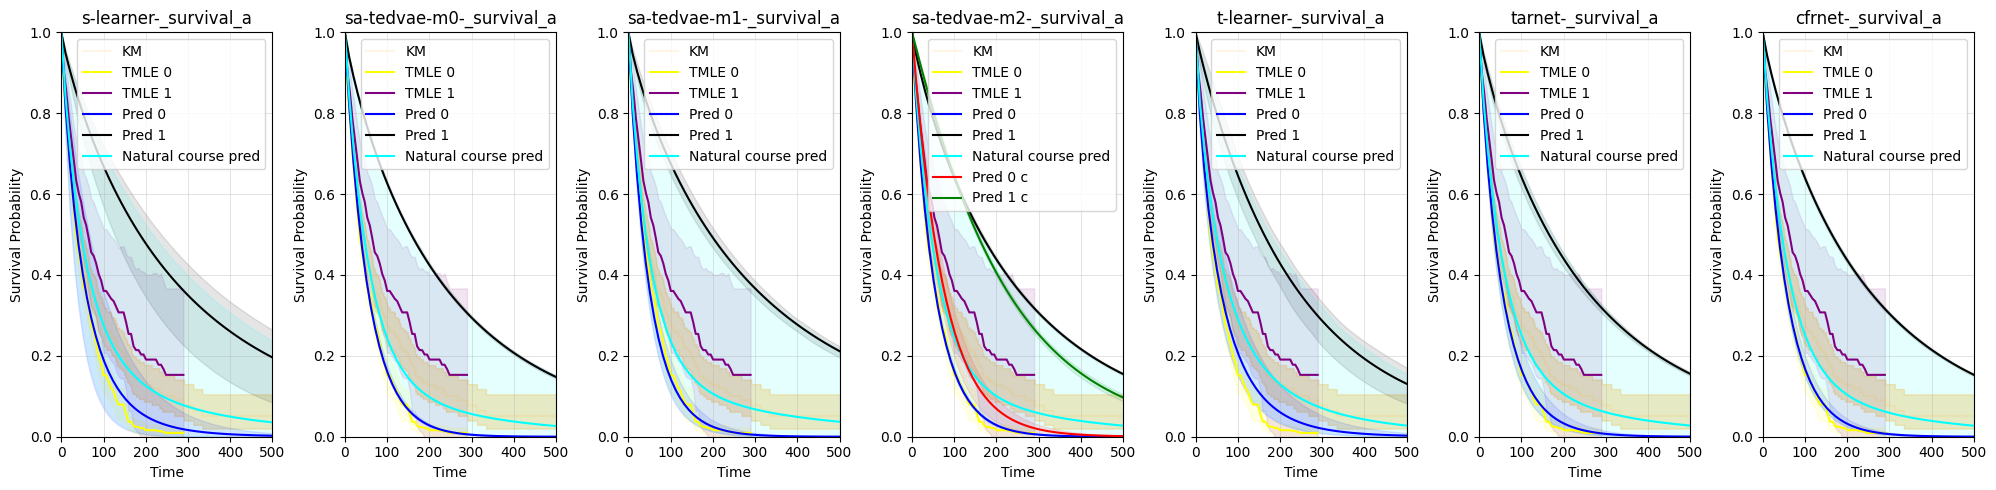

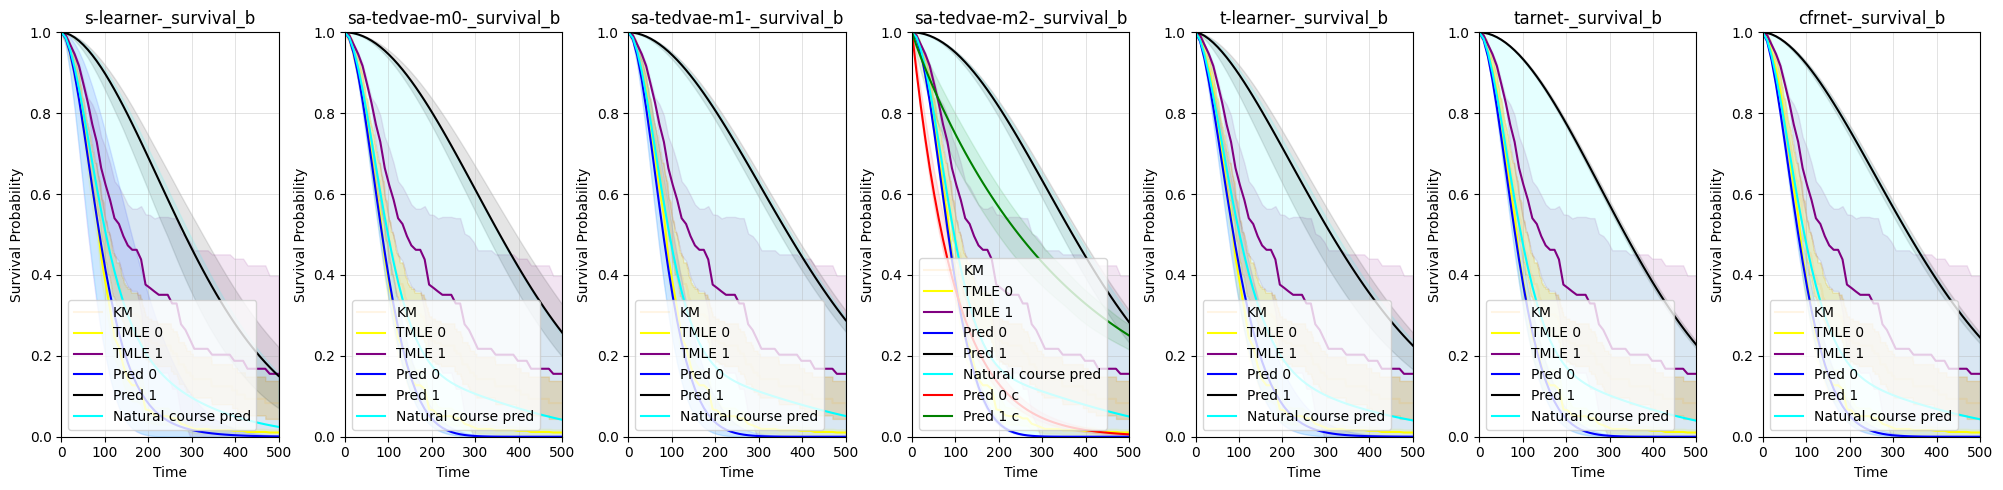

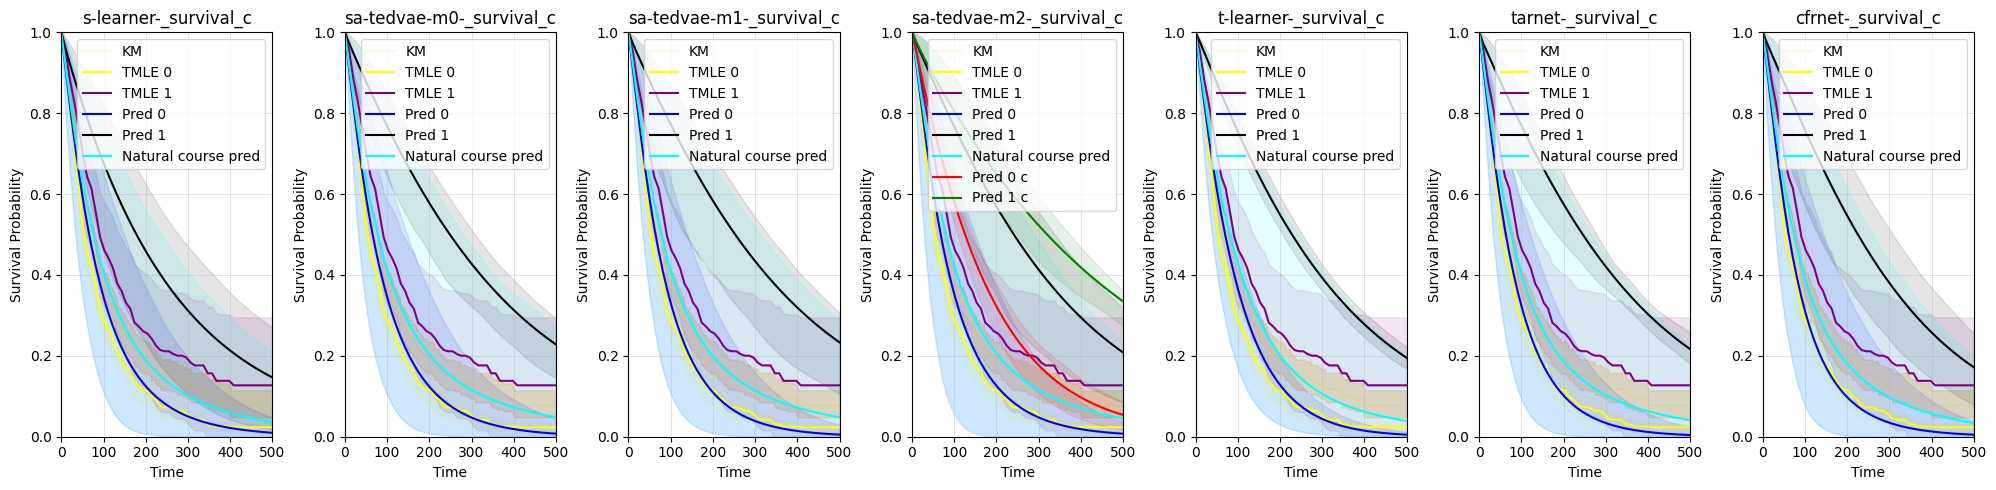

In [24]:
# Plot the aggregate predictions over all patients compared to the natural course FOR A SINGLE DATASET, WITH TMLE
max_t = 500
time_vector = np.linspace(0, max_t, 50)  # Vector to plot the time
models_to_plot = ['s-learner', 'sa-tedvae-m0', 'sa-tedvae-m1', 'sa-tedvae-m2', 't-learner', 'tarnet', 'cfrnet']
i = 0  # Dataset index to plot, change this to plot different datasets

def aux_plot(arrays, label, color, percentile=5, additional_arrays=None, t=None):
    arrays = np.array(arrays).squeeze()
    if additional_arrays is not None:
        additional_arrays = np.array(additional_arrays).squeeze()
        new_arrays = np.zeros_like(arrays)
        for i in range(arrays.shape[0]):
            new_arrays[i, :] = additional_arrays[i, :] * t[i] + arrays[i, :] * (1 - t[i])  # Assumes additional list of arrays is t=1
        arrays = new_arrays
    mean_val, std_val = np.mean(arrays, axis=0), np.std(arrays, axis=0)
    low_val, high_val = np.percentile(arrays, percentile, axis=0), np.percentile(arrays, 100 - percentile, axis=0)
    plt.fill_between(time_vector, low_val, high_val, color=color, alpha=0.1)
    plt.plot(time_vector, mean_val, label=label, color=color)


for setting in settings:

    plt.subplots(1, len(models), figsize=(20, 5))
    model_index_plot = 1

    for model_name in models:

        plt.subplot(1, len(models), model_index_plot)

        ihdp_data = load_data(i=i + 1, setting=setting)  # Use all the data for KM
        all_y = np.concatenate([ihdp_data['y_train'], ihdp_data['y_test']])
        all_c = np.concatenate([ihdp_data['c_train'], ihdp_data['c_test']])

        kmf = KaplanMeierFitter()
        kmf.fit(all_y, event_observed=1 - all_c)
        kmf.plot_survival_function(label='KM', color='orange', alpha=0.1)

        # Add TMLE
        tmle_est = results_tmle[setting][models[0]]['pred_tmle'][i]  # Note that we store TMLE in the first model
        time0 = tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 0)]["Time"].values
        mean0 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 0)]["Pt Est"].values
        ci_lower0 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 0)]["CI_lower"].values
        ci_upper0 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 0)]["CI_upper"].values
        time1 = tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 1)]["Time"].values
        mean1 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 1)]["Pt Est"].values
        ci_lower1 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 1)]["CI_lower"].values
        ci_upper1 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 1)]["CI_upper"].values

        plt.fill_between(time0, ci_lower0, ci_upper0, alpha=0.1, color='yellow')
        plt.plot(time0, mean0, label='TMLE 0', color='yellow')
        plt.fill_between(time1, ci_lower1, ci_upper1, alpha=0.1, color='purple')
        plt.plot(time1, mean1, label='TMLE 1', color='purple')

        curves = {'survival_test_0_censor_pred': [], 'survival_test_1_censor_pred': [],
                  'survival_test_0_outcome_pred': [],
                  'survival_test_1_outcome_pred': []}

        data_dict = {'outcome_scale_train': [o for o in results[setting][model_name]['outcome_scale_train'][i]],
                     'outcome_scale_test': [o for o in results[setting][model_name]['outcome_scale_test'][i]],
                     'outcome_concentration_train': [o for o in
                                                     results[setting][model_name]['outcome_concentration_train'][i]],
                     'outcome_concentration_test': [o for o in
                                                    results[setting][model_name]['outcome_concentration_test'][i]]}
        if model_name == 'sa-tedvae-m2':
            data_dict['censor_scale_train'] = [o for o in results[setting][model_name]['censor_scale_train'][i]]
            data_dict['censor_scale_test'] = [o for o in results[setting][model_name]['censor_scale_test'][i]]
            data_dict['censor_concentration_train'] = [o for o in
                                                       results[setting][model_name]['censor_concentration_train'][i]]
            data_dict['censor_concentration_test'] = [o for o in
                                                      results[setting][model_name]['censor_concentration_test'][i]]
        survival_train_0_censor_pred, survival_test_0_censor_pred, survival_train_1_censor_pred, survival_test_1_censor_pred, survival_train_0_outcome_pred, survival_test_0_outcome_pred, survival_train_1_outcome_pred, survival_test_1_outcome_pred = get_pred_ihdp_curves(data_dict, time_vector)

        curves['survival_test_0_outcome_pred'].append(survival_test_0_outcome_pred.T)
        curves['survival_test_1_outcome_pred'].append(survival_test_1_outcome_pred.T)
        if model_name == 'sa-tedvae-m2':
            curves['survival_test_0_censor_pred'].append(survival_test_0_censor_pred.T)
            curves['survival_test_1_censor_pred'].append(survival_test_1_censor_pred.T)

        aux_plot(curves['survival_test_0_outcome_pred'], label=f"Pred 0", color='blue')
        aux_plot(curves['survival_test_1_outcome_pred'], label=f"Pred 1", color='black')
        # Add the natural course
        aux_plot(curves['survival_test_0_outcome_pred'], label=f"Natural course pred", color='cyan', additional_arrays=curves['survival_test_1_outcome_pred'], t=ihdp_data['t_test'])
        if model_name == 'sa-tedvae-m2':
            aux_plot(curves['survival_test_0_censor_pred'], label=f"Pred 0 c", color='red')
            aux_plot(curves['survival_test_1_censor_pred'], label=f"Pred 1 c", color='green')

        plt.title(f"{model_name}-{setting}")
        plt.xlabel("Time")
        plt.ylabel("Survival Probability")
        plt.ylim([0, 1])
        plt.xlim([0, max_t])
        plt.grid(True)
        plt.legend(loc='best')
        model_index_plot += 1
    plt.tight_layout()
    plt.show()
